# 2025-03-29 - Taxonomy

In this notebook, we will analyze the MMSeqs2 taxonomy results. Some of the questions that we hope to address here:
- Can we elaborate which bacteria class/families/order/genres/species are pressent in the sample?
- Can we use this tool to detect bacteria pathogens?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm
import taxoniq
from seaborn import objects as so
import numpy as np
sns.set_style('ticks')
plt.rcParams['svg.fonttype'] = 'none'

## Reading data

The data is stored under different TSV files —one per library. Reading should be easy.

In [2]:
def load_library_taxonomy_results(file, path, library):
    """
    assigning labels from reading https://mmseqs.com/latest/userguide.pdf, taxonomy output and TSV
    """
    u = pd.read_csv(
        path + '/' + file, 
        sep='\t', 
        header=None, 
        index_col=None,
        names=['seq_id', 'taxid', 'level', 'species_name', 'fragments', 'frag_labeled', 'agreement', 'support']
    )
    u['library'] = library

    return u[['library', 'seq_id', 'taxid', 'level', 'species_name', 'fragments', 'support']]


In [3]:
load_library_taxonomy_results(
    "PV146.taxonomy.tsv", 
    "/home/bcz/research/miripvir25/results/2025-03-19-kraken2-mmseqs2-run",
    "PV146"
)

,library,seq_id,taxid,level,species_name,fragments,support
0,PV146,J00148:81:HNGTKBBXX:1:1118:19086:25597,0,no rank,unclassified,1,0.0
1,PV146,J00148:81:HNGTKBBXX:1:1119:12094:29765,0,no rank,unclassified,1,0.0
2,PV146,J00148:81:HNGTKBBXX:1:1117:11525:9543,0,no rank,unclassified,1,0.0
3,PV146,J00148:81:HNGTKBBXX:1:1118:14174:3125,0,no rank,unclassified,1,0.0
4,PV146,J00148:81:HNGTKBBXX:1:2108:16924:23048,2,superkingdom,Bacteria,2,1.0
...,...,...,...,...,...,...,...
65189,PV146,J00148:81:HNGTKBBXX:1:2211:17766:13324,0,no rank,unclassified,1,0.0
65190,PV146,J00148:81:HNGTKBBXX:1:2212:25540:2246,0,no rank,unclassified,1,0.0
65191,PV146,J00148:81:HNGTKBBXX:1:2209:11911:26529,2,superkingdom,Bacteria,2,1.0
65192,PV146,J00148:81:HNGTKBBXX:1:2210:11119:23962,2,superkingdom,Bacteria,2,1.0


In [4]:
import re

In [5]:
def fix_numeric_format_issues(x):
    m = re.search("PV(\d{1,6})(\w{1,10})?", x)
    m = list(m.groups())
    if m[1] is not None:
        return 'PV{:03d}{:s}'.format(int(m[0]), m[1])
    else:
        return 'PV{:03d}'.format(int(m[0]))
    
print(fix_numeric_format_issues("PV03bgi"))
print(fix_numeric_format_issues("PV00003bgi"))
print(fix_numeric_format_issues("PV00003"))
print(fix_numeric_format_issues("PV00003asdasda"))

PV003bgi
PV003bgi
PV003
PV003asdasda


In [6]:
input_reference = pd.read_csv("/home/bcz/research/miripvir25/results/2025-03-19-kraken2-mmseqs2-run/.input", header=None, names=["file"])
input_reference['library'] = input_reference['file'].apply(lambda x: fix_numeric_format_issues(x))
input_reference

,file,library
0,PV003bgi.taxonomy.tsv,PV003bgi
1,PV004bgi.taxonomy.tsv,PV004bgi
2,PV005bgi.taxonomy.tsv,PV005bgi
3,PV006bgi.taxonomy.tsv,PV006bgi
4,PV007bgi.taxonomy.tsv,PV007bgi
...,...,...
313,PV96.taxonomy.tsv,PV096
314,PV97.taxonomy.tsv,PV097
315,PV98.taxonomy.tsv,PV098
316,PV99.taxonomy.tsv,PV099


In [7]:
taxonomy_output = []
for i, row in tqdm.tqdm(list(input_reference.iterrows())):
    tmp = load_library_taxonomy_results(
        row.file, 
        "/home/bcz/research/miripvir25/results/2025-03-19-kraken2-mmseqs2-run",
        row.library
    )
    taxonomy_output.append(tmp)
taxonomy_output = pd.concat(taxonomy_output)
taxonomy_output

  0%|          | 0/318 [00:00<?, ?it/s]

100%|██████████| 318/318 [01:00<00:00,  5.22it/s]


,library,seq_id,taxid,level,species_name,fragments,support
0,PV003bgi,ST-E00169:248:H5VT5ALXX:5:1101:26007:5686,0,no rank,unclassified,1,0.0
1,PV003bgi,ST-E00169:248:H5VT5ALXX:5:1101:28899:66812,0,no rank,unclassified,1,0.0
2,PV003bgi,ST-E00169:248:H5VT5ALXX:5:1109:18923:5827,0,no rank,unclassified,1,0.0
3,PV003bgi,ST-E00169:248:H5VT5ALXX:5:1103:22719:38034,0,no rank,unclassified,1,0.0
4,PV003bgi,ST-E00169:248:H5VT5ALXX:5:1101:18558:53926,0,no rank,unclassified,1,0.0
...,...,...,...,...,...,...,...
140551,PV009,J00148:8:HFKGWBBXX:2:1119:26910:9403,0,no rank,unclassified,1,0.0
140552,PV009,J00148:8:HFKGWBBXX:2:1119:6076:24894,0,no rank,unclassified,1,0.0
140553,PV009,J00148:8:HFKGWBBXX:2:1119:18680:41141,0,no rank,unclassified,1,0.0
140554,PV009,J00148:8:HFKGWBBXX:2:1120:15412:14590,0,no rank,unclassified,1,0.0


## Coverage 

How many sequences are we classifying? 
Once we know this fact, we can get rid of the unclassified sequences.

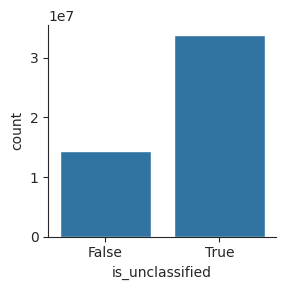

In [8]:
taxonomy_output['is_unclassified'] = taxonomy_output['taxid'] == 0
sns.catplot(
    taxonomy_output.value_counts(subset=['is_unclassified']).reset_index(), 
    x='is_unclassified', y='count', height=3.0, aspect=1.0, kind='bar'
)

Now we will get rid of those unclassified.

In [9]:
taxonomy_output = taxonomy_output.query('is_unclassified == False').copy()

## Taxonomic level assignments

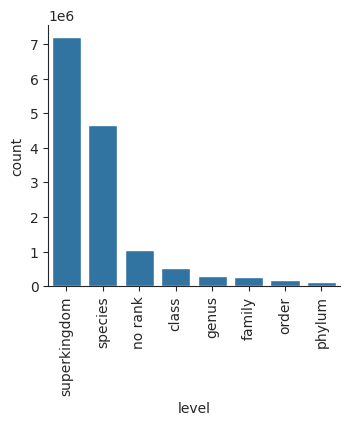

In [10]:
g = sns.catplot(
    data=taxonomy_output.value_counts(subset=['level']).reset_index(),
    x='level', y='count', kind='bar', height=3.5
)
g.set_xticklabels(rotation=90)

It seems that we recover quite a decent assignment

## Taxonomy assignments

GTDB taxonomy is a bit tricky, as it is different than the standard NCBI taxonomy codes. Indeed, the GTDB codes do not exist, they were created only for the purpose of GTDB mapping. Therefore, we need to work around this limitation.

In [11]:

class GTDB_taxonomy:

    def __init__(self, names, nodes):
        
        nodes = pd.read_csv(nodes, sep="\t\|\t", header=None, names=['taxid', 'parent', 'rank', '_'])[['taxid', 'parent', 'rank']]
        names = pd.read_csv(names, sep="\t\|\t", header=None, names=['taxid', 'scientific_name', '_', '__'])[['taxid', 'scientific_name']]
        nodes = pd.merge(nodes, names, on='taxid')
        nodes['t'] = nodes['taxid'].copy()
        self.nodes = nodes.set_index('t')
        self.parents = self.build_lineages_dict(nodes)

    @staticmethod
    def build_lineages_dict(nodes):
        parent_dict = dict()
        for _, node in nodes.iterrows():
            parent_dict[node.taxid] = node.parent
        return parent_dict

    def lineage(self, taxid):
        
        lineage = []
        
        lineage.append(self.nodes.loc[taxid].to_dict())
        max_depth = 20
        i = 0
        while lineage[-1]['taxid'] != 1 and i < max_depth:
            parent = self.nodes.loc[self.parents[taxid]].to_dict()
            lineage.append(parent)
            taxid = parent['taxid']
            i += 1
        return lineage

In [12]:
gtdbtax = GTDB_taxonomy(
    "../data/taxonomy/gtdb-taxdump/names.dmp",
    "../data/taxonomy/gtdb-taxdump/nodes.dmp"
)

/tmp/ipykernel_563598/3342168440.py:5: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  nodes = pd.read_csv(nodes, sep="\t\|\t", header=None, names=['taxid', 'parent', 'rank', '_'])[['taxid', 'parent', 'rank']]
/tmp/ipykernel_563598/3342168440.py:6: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  names = pd.read_csv(names, sep="\t\|\t", header=None, names=['taxid', 'scientific_name', '_', '__'])[['taxid', 'scientific_name']]


In [13]:
# taxonomy_reference = []
# for taxid in tqdm.tqdm(taxonomy_output.tax_id.unique()):
#     m = pd.DataFrame(gtdbtax.lineage(taxid))
#     m['taxid'] = taxid
#     m = m.pivot(index='taxid', columns='rank', values='scientific_name').reset_index()# .reset_index()
#     taxonomy_reference.append(m.loc[0].to_dict())

# taxonomy_reference = pd.DataFrame.from_records(taxonomy_reference)
# taxonomy_reference[['taxid', 'superkingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species']].to_json("../results/2025-03-19-kraken2-mmseqs2-run/gtdb-taxonomy-reference.json")

# 

In [14]:
taxonomy_reference = pd.read_json("../results/2025-03-19-kraken2-mmseqs2-run/gtdb-taxonomy-reference.json")

## Class assignments

We will be working at class level, for which goal we will proceed to remove all the samples that are not classified at rank class or lower.

In [15]:
taxonomy_output = pd.merge(taxonomy_output, taxonomy_reference, on='taxid')
taxonomy_output = taxonomy_output.dropna(subset='class').copy()

In [16]:
class_14 = taxonomy_output.value_counts(
    subset=['library', 'taxid', 'class']
).reset_index().groupby(
    ['class'], as_index=False
)['count'].sum().sort_values(
    by='count', ascending=False
)['class'].tolist()[:9]
taxonomy_output['class15'] = taxonomy_output['class'].apply(lambda x: x if x in class_14 else "Other")

## Sites assignments

Most of the downstream analysis that we aim to carry out depend on spatial assignments. We merge our dataset with a reference table that determines the sampling site.

In [17]:
mc24_table1 = pd.read_csv("/home/bcz/research/miripvir25/data/mcleish2024/nph20054-sup-0002-TablesS1.csv", sep=';')
mc24_table2 = pd.read_csv("/home/bcz/research/miripvir25/data/mcleish2024/nph20054-sup-0002-TablesS2.csv", sep=';')
mc24_table2 = mc24_table2.dropna(subset=['Library_code'])
mc24_table2['Collection_code'] = mc24_table2['Collection_code'].apply(lambda x: x.split("_")[0])
sample_reference = pd.merge(mc24_table1, mc24_table2, on='Collection_code').groupby(['Site_code', 'Collection_code', 'Library_code', 'Location', 'Host_taxon', 'Habitat', 'No_extracts'], as_index=False)['Date'].apply(lambda x: len(list(x)))
sample_reference

,Site_code,Collection_code,Library_code,Location,Host_taxon,Habitat,No_extracts,Date
0,C1,C1F,PV534,Aranjuez,Diplotaxis erucoides,Crop,3.0,1
1,C1,C1F,PV535,Aranjuez,Brassica oleracea,Crop,17.0,1
2,C1,C1F,PV538,Aranjuez,Brassica oleracea,Crop,8.0,1
3,C1,C1F,PV540,Aranjuez,Picris echioides,Crop,1.0,1
4,C1,C1F,PV544,Aranjuez,Sisymbrium runcinatum,Crop,4.0,1
...,...,...,...,...,...,...,...,...
318,Z1,Z1V,PV590,Villaconejos,Zea mays,Crop,11.0,1
319,Z2,Z2V,PV047,Villamanrique de Tajo,Zea mays,Crop,13.0,1
320,Z2,Z2V,PV048,Villamanrique de Tajo,Desconocida 4,Crop,9.0,1
321,Z2,Z2V,PV527,Villamanrique de Tajo,Convolvulus arvensis,Crop,4.0,1


In [18]:
taxonomy_output = pd.merge(taxonomy_output, sample_reference, left_on='library', right_on='Library_code')

### Class relative abundances

In [19]:
taxonomy_output_classcounts = taxonomy_output.value_counts(['Site_code', 'class15']).reset_index().sort_values(by='Site_code')
taxonomy_output_classtotalcounts = taxonomy_output.value_counts(['Site_code']).reset_index().sort_values(by='Site_code').rename(columns={'count': 'total'})
taxonomy_output_classcounts = pd.merge(taxonomy_output_classcounts, taxonomy_output_classtotalcounts, on='Site_code')
taxonomy_output_classcounts['AR'] = taxonomy_output_classcounts['count'] / taxonomy_output_classcounts['total']
taxonomy_output_classcounts.pivot(index='Site_code', columns='class15', values='AR')

class15,Actinomycetes,Alphaproteobacteria,Bacilli,Bacteroidia,Clostridia,Cyanobacteriia,Gammaproteobacteria,Other,Paceibacteria,Verrucomicrobiae
Site_code,,,,,,,,,,
C1,0.146166,0.080834,0.087001,0.195100,0.103685,0.067929,0.144504,0.144426,0.012269,0.018086
C2,0.111088,0.090805,0.095668,0.216878,0.090892,0.071180,0.159455,0.131606,0.003672,0.028755
E1,0.134107,0.099396,0.047014,0.198585,0.077370,0.098534,0.130474,0.141517,0.049652,0.023352
E2,0.147887,0.071385,0.041464,0.201025,0.054219,0.088798,0.113103,0.193119,0.079118,0.009880
E3,0.125317,0.079854,0.042676,0.165727,0.061645,0.071753,0.255800,0.141789,0.040671,0.014768
E4,0.103904,0.106139,0.037321,0.087381,0.057446,0.045055,0.363868,0.132438,0.005139,0.061309
H1,0.060306,0.067214,0.027117,0.249504,0.003343,0.071331,0.223054,0.211715,0.083858,0.002561
H2,0.174460,0.067450,0.071058,0.115736,0.098560,0.065627,0.178970,0.147380,0.003829,0.076930
H3,0.098300,0.050334,0.031549,0.103820,0.049825,0.051422,0.478745,0.080119,0.011422,0.044464


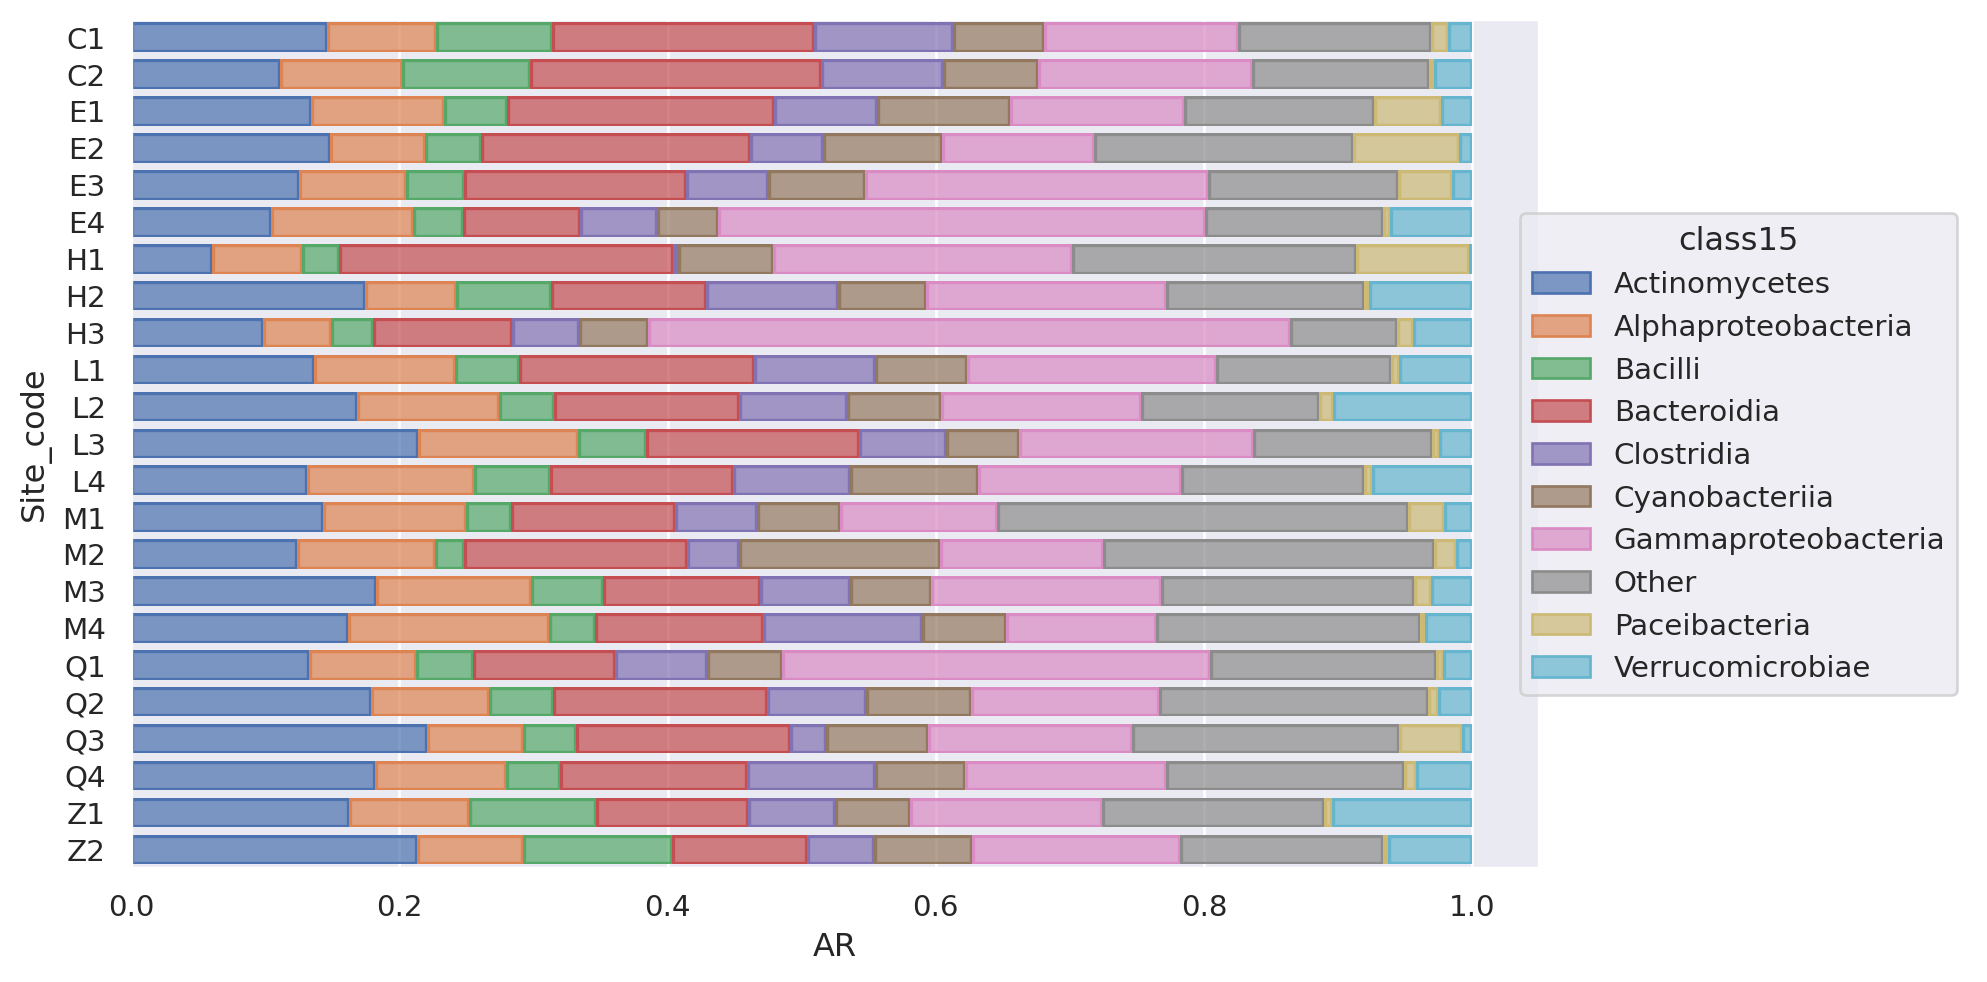

In [20]:
(
    so.Plot(
        data=taxonomy_output_classcounts.sort_values(by=['Site_code', 'class15']), 
        x="AR", y="Site_code", color="class15"
    ).add(
        so.Bar(), so.Stack()
    ).layout(
        size=(8,5), engine='constrained'
    )

)

In [21]:
from scipy.spatial.distance import braycurtis

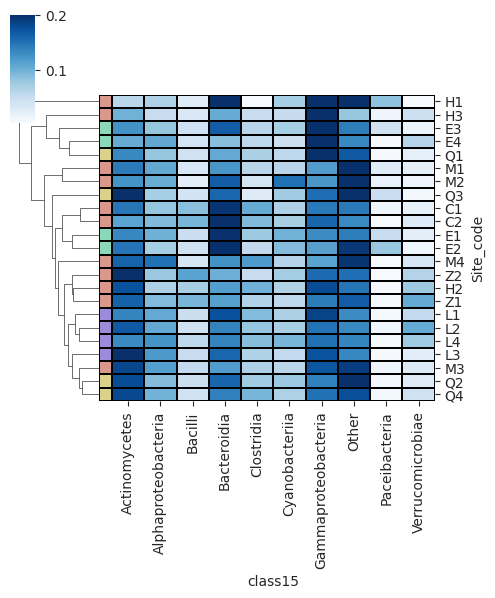

In [22]:
taxonomy_output_classcounts['lAR'] = taxonomy_output_classcounts['AR'].apply(lambda x: np.log10(x + 1e-6))
taxonomy_output_classcounts_pvt = taxonomy_output_classcounts.pivot(index='Site_code', columns='class15', values='AR')
site_codes = taxonomy_output_classcounts_pvt.reset_index()['Site_code']
habitat_dict = sample_reference.drop_duplicates(['Site_code'])[['Site_code', 'Habitat']].set_index('Site_code').to_dict()['Habitat']
habitats = [habitat_dict[item] for item in site_codes]

palette = {
    "Crop": "#D9988B", 
    "Edge": "#9C8BD9", 
    "Oak": "#DAD28C",
    "Wasteland": "#8BD9BA"
}

row_colors = [palette[item] for item in habitats]
g = sns.clustermap(
    taxonomy_output_classcounts_pvt, cmap='Blues', 
    figsize=(5, 6), metric=braycurtis, row_colors=row_colors, 
    col_cluster=False, linewidths=0.1, linecolor="black",vmax=0.2
)
# g.savefig("../figures/gtdb-mmseqs2/class.clustermap.svg")

## Host role / average AR 

In [23]:
taxonomy_output

,library,seq_id,taxid,level,species_name,fragments,support,is_unclassified,superkingdom,phylum,...,species,class15,Site_code,Collection_code,Library_code,Location,Host_taxon,Habitat,No_extracts,Date
0,PV003bgi,ST-E00169:248:H5VT5ALXX:5:1103:31974:10644,100465,species,UBA6053 sp937127435,2,1.0,False,Bacteria,Verrucomicrobiota,...,UBA6053 sp937127435,Other,M1,M1V,PV003bgi,Aranjuez,Cucumis melo,Crop,13.0,1
1,PV003bgi,ST-E00169:248:H5VT5ALXX:5:2114:4208:50340,95757,species,Shewanella sp022321485,1,1.0,False,Bacteria,Pseudomonadota,...,Shewanella sp022321485,Gammaproteobacteria,M1,M1V,PV003bgi,Aranjuez,Cucumis melo,Crop,13.0,1
2,PV003bgi,ST-E00169:248:H5VT5ALXX:5:2113:12489:68025,80289,species,Sinorhizobium shofinae,2,1.0,False,Bacteria,Pseudomonadota,...,Sinorhizobium shofinae,Alphaproteobacteria,M1,M1V,PV003bgi,Aranjuez,Cucumis melo,Crop,13.0,1
3,PV003bgi,ST-E00169:248:H5VT5ALXX:5:2107:16691:12507,80289,species,Sinorhizobium shofinae,2,1.0,False,Bacteria,Pseudomonadota,...,Sinorhizobium shofinae,Alphaproteobacteria,M1,M1V,PV003bgi,Aranjuez,Cucumis melo,Crop,13.0,1
4,PV003bgi,ST-E00169:248:H5VT5ALXX:5:2108:20253:8798,3824,species,Otoolea sp009911305,2,1.0,False,Bacteria,Bacillota A,...,Otoolea sp009911305,Clostridia,M1,M1V,PV003bgi,Aranjuez,Cucumis melo,Crop,13.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5834672,PV009,J00148:8:HFKGWBBXX:2:1213:3752:31734,16871,genus,Geminocystis,2,1.0,False,Bacteria,Cyanobacteriota,...,None,Cyanobacteriia,Q1,Q1F,PV009,Aranjuez,Quercus coccifera,Oak,13.0,2
5834673,PV009,J00148:8:HFKGWBBXX:2:1101:29954:32859,509,order,Chlamydiales,2,1.0,False,Bacteria,Chlamydiota,...,None,Other,Q1,Q1F,PV009,Aranjuez,Quercus coccifera,Oak,13.0,2
5834674,PV009,J00148:8:HFKGWBBXX:2:1202:6350:22731,57157,species,Phaeospirillum magnetica A,2,1.0,False,Bacteria,Pseudomonadota,...,Phaeospirillum magnetica A,Alphaproteobacteria,Q1,Q1F,PV009,Aranjuez,Quercus coccifera,Oak,13.0,2
5834675,PV009,J00148:8:HFKGWBBXX:2:1203:18812:26353,5,order,Enterobacterales,4,1.0,False,Bacteria,Pseudomonadota,...,None,Gammaproteobacteria,Q1,Q1F,PV009,Aranjuez,Quercus coccifera,Oak,13.0,2


In [24]:
taxonomy_output_hostrole_counts = taxonomy_output.value_counts(['library', 'Host_taxon', 'taxid']).reset_index().sort_values(by='library')
taxonomy_output_hostrole_totalcounts = taxonomy_output.value_counts(['library']).reset_index().sort_values(by='library').rename(columns={'count': 'total'})
taxonomy_output_hostrole_counts = pd.merge(taxonomy_output_hostrole_counts, taxonomy_output_hostrole_totalcounts, on='library')
taxonomy_output_hostrole_counts['AR'] = taxonomy_output_hostrole_counts['count'] / taxonomy_output_hostrole_counts['total']
taxonomy_output_hostrole_counts
# taxonomy_output_hostrole_counts.pivot(index='Library', columns='class15', values='AR')

,library,Host_taxon,taxid,count,total,AR
0,PV001,Amaranthus sp,109099,7,4079,0.001716
1,PV001,Amaranthus sp,18353,1,4079,0.000245
2,PV001,Amaranthus sp,18973,1,4079,0.000245
3,PV001,Amaranthus sp,21219,3,4079,0.000735
4,PV001,Amaranthus sp,18700,1,4079,0.000245
...,...,...,...,...,...,...
507280,PV590,Zea mays,57706,1,6671,0.000150
507281,PV590,Zea mays,57315,1,6671,0.000150
507282,PV590,Zea mays,56878,1,6671,0.000150
507283,PV590,Zea mays,49980,1,6671,0.000150


In [25]:
taxonomy_output_hostrole_counts = pd.merge(taxonomy_output_hostrole_counts, taxonomy_output_hostrole_counts.value_counts(subset=['taxid', 'Host_taxon']).reset_index().value_counts('taxid').reset_index().rename(columns={'count':  'host_range'}), on='taxid')

In [26]:
taxonomy_output_hostrole_counts

,library,Host_taxon,taxid,count,total,AR,host_range
0,PV001,Amaranthus sp,109099,7,4079,0.001716,115
1,PV001,Amaranthus sp,18353,1,4079,0.000245,91
2,PV001,Amaranthus sp,18973,1,4079,0.000245,100
3,PV001,Amaranthus sp,21219,3,4079,0.000735,112
4,PV001,Amaranthus sp,18700,1,4079,0.000245,1
...,...,...,...,...,...,...,...
507280,PV590,Zea mays,57706,1,6671,0.000150,8
507281,PV590,Zea mays,57315,1,6671,0.000150,58
507282,PV590,Zea mays,56878,1,6671,0.000150,7
507283,PV590,Zea mays,49980,1,6671,0.000150,21


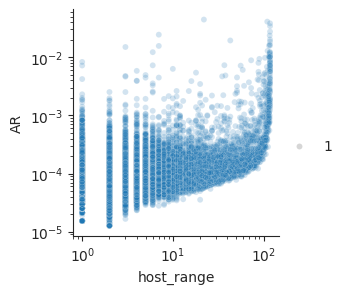

In [27]:
g = sns.relplot(
    taxonomy_output_hostrole_counts.groupby('taxid')[['AR', 'host_range']].mean(), 
    x='host_range', y='AR', height=3.0, markers='.', alpha=0.2, size=1
)
g.axes[0, 0].set_yscale('log')
g.axes[0, 0].set_xscale('log')

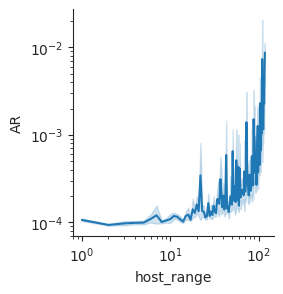

In [28]:
g = sns.relplot(
    taxonomy_output_hostrole_counts.groupby('taxid')[['AR', 'host_range']].mean(), 
    x='host_range', y='AR', height=3.0, markers='.', alpha=1.0, kind='line'
)
g.axes[0, 0].set_yscale('log')
g.axes[0, 0].set_xscale('log')
# g.savefig("../figures/gtdb-mmseqs2/host-range-ar.plot.svg")

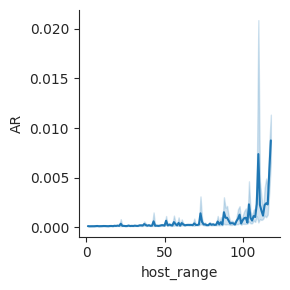

In [29]:
g = sns.relplot(
    taxonomy_output_hostrole_counts.groupby('taxid')[['AR', 'host_range']].mean(), 
    x='host_range', y='AR', height=3.0, markers='.', alpha=1.0, kind='line'
)
# g.axes[0, 0].set_yscale('log')
# g.axes[0, 0].set_xscale('log')

## Subsetting to Sanchis21

There are two possible issues affecting our analysis:
- Too much noise, due to excessive taxonomy mapping. 
- Too much noise, due to errors on the sequencing.

Therefore, we will:
- Remove all hits that have less than 50 reads per sample.
- Subset all reads to Sanchis21 database of phytopathogens and phytosymbionts.

In [30]:
taxonomy_output_counts = taxonomy_output.value_counts(
    subset=[
        'library', 'taxid', 'level', 'species_name', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'Site_code', 
        'Collection_code', 'Host_taxon', 'Habitat'
    ]
).reset_index()

In [31]:
taxonomy_output_counts

,library,taxid,level,species_name,phylum,class,order,family,genus,species,Site_code,Collection_code,Host_taxon,Habitat,count
0,PV423,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,Q1,Q1P,Bromus sp,Oak,56742
1,PV428,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,Q1,Q1P,Hordeum matritense,Oak,56005
2,PV356,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,E3,E3P,Hordeum matritense,Wasteland,52262
3,PV085,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,E4,E4P,Avena sterilis,Wasteland,43396
4,PV078,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,E4,E4F,Bromus sp,Wasteland,31948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
363465,PV193,135138,species,JANQGV01 sp028282925,Desulfobacterota,WTBG01,CAIYCZ01,CAIRTM01,JANQGV01,JANQGV01 sp028282925,L2,L2P,Galium verum,Edge,1
363466,PV193,135300,species,OXYB2-FULL-48-7 sp001800495,Elusimicrobiota,Endomicrobiia,CG1-02-37-114,XYA2-FULL-39-19,OXYB2-FULL-48-7,OXYB2-FULL-48-7 sp001800495,L2,L2P,Galium verum,Edge,1
363467,PV087,42708,species,F1-120-MAGs055 sp005779395,Actinomycetota,Acidimicrobiia,IMCC26256,PALSA-610,F1-120-MAGs055,F1-120-MAGs055 sp005779395,E4,E4P,Echium vulgare,Wasteland,1
363468,PV087,42661,species,Sulfotelmatobacter sp003156805,Acidobacteriota,Terriglobia,Terriglobales,SbA1,Sulfotelmatobacter,Sulfotelmatobacter sp003156805,E4,E4P,Echium vulgare,Wasteland,1


In [34]:
taxonomy_output_counts['Lcount']  = taxonomy_output_counts['count'].apply(np.log10)

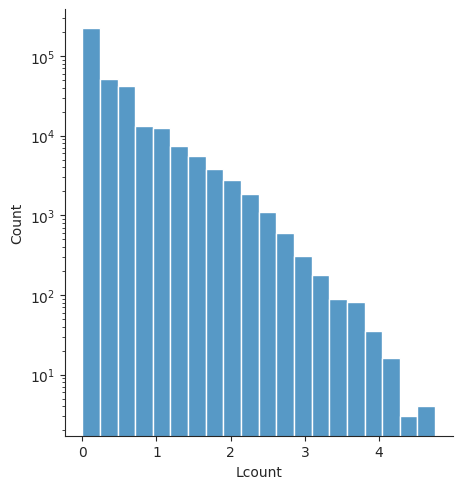

In [37]:
g = sns.displot(taxonomy_output_counts, x='Lcount', bins=20)
g.axes[0,0].set_yscale('log')

In [42]:
taxonomy_output_counts_c10 = taxonomy_output_counts.query('count > 10')

In [43]:
taxonomy_output_counts_c10

,library,taxid,level,species_name,phylum,class,order,family,genus,species,Site_code,Collection_code,Host_taxon,Habitat,count,Lcount
0,PV423,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,Q1,Q1P,Bromus sp,Oak,56742,4.753905
1,PV428,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,Q1,Q1P,Hordeum matritense,Oak,56005,4.748227
2,PV356,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,E3,E3P,Hordeum matritense,Wasteland,52262,4.718186
3,PV085,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,E4,E4P,Avena sterilis,Wasteland,43396,4.637450
4,PV078,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,E4,E4F,Bromus sp,Wasteland,31948,4.504444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31548,PV155,51238,species,Parasynechococcus sp002690325,Cyanobacteriota,Cyanobacteriia,PCC-6307,Cyanobiaceae,Parasynechococcus,Parasynechococcus sp002690325,L4,L4P,Fumaria parviflora,Edge,11,1.041393
31549,PV087,88840,species,CADCWF01 sp029977305,Chloroflexota,Chloroflexia,Thermomicrobiales,UBA6265,CADCWF01,CADCWF01 sp029977305,E4,E4P,Echium vulgare,Wasteland,11,1.041393
31550,PV104,9743,species,Limosilactobacillus sp946579075,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Limosilactobacillus,Limosilactobacillus sp946579075,Q2,Q2P,Dactylis glomerata,Oak,11,1.041393
31551,PV174,68578,species,JALSIX01 sp026989655,Chloroflexota,Anaerolineae,Caldilineales,Caldilineaceae,JALSIX01,JALSIX01 sp026989655,L2,L2V,Silybum marianum,Edge,11,1.041393


In [46]:
to_c10 = pd.merge(taxonomy_output_counts_c10, pd.read_json("../data/2025-04-20-sanchis21-gtdb-ncbi.json"), left_on=['taxid'], right_on=['gtdb_id'])

In [63]:
to_c10

,library,taxid,level,species_name,phylum,class,order,family,genus,species,...,Host_taxon,Habitat,count,Lcount,accession,gtdb_id,ncbi_organism_name,ncbi_species_taxid,ncbi_taxid,ncbi_genbank_assembly_accession
0,PV217,3504,species,Acinetobacter courvalinii,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Moraxellaceae,Acinetobacter,Acinetobacter courvalinii,...,Datura stramonium,Edge,3342,3.524006,GB_GCA_008764415.1,3504,Acinetobacter baumannii,470,470,GCA_008764415.1
1,PV217,3504,species,Acinetobacter courvalinii,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Moraxellaceae,Acinetobacter,Acinetobacter courvalinii,...,Datura stramonium,Edge,3342,3.524006,GB_GCA_000580655.1,3504,Acinetobacter baumannii 146457,470,1310623,GCA_000580655.1
2,PV217,3504,species,Acinetobacter courvalinii,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Moraxellaceae,Acinetobacter,Acinetobacter courvalinii,...,Datura stramonium,Edge,3342,3.524006,GB_GCA_003978795.1,3504,Acinetobacter baumannii,470,470,GCA_003978795.1
3,PV217,3504,species,Acinetobacter courvalinii,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Moraxellaceae,Acinetobacter,Acinetobacter courvalinii,...,Datura stramonium,Edge,3342,3.524006,GB_GCA_000580915.1,3504,Acinetobacter baumannii 1437282,470,1310638,GCA_000580915.1
4,PV224,3504,species,Acinetobacter courvalinii,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Moraxellaceae,Acinetobacter,Acinetobacter courvalinii,...,Vicia sp,Edge,2056,3.313023,GB_GCA_008764415.1,3504,Acinetobacter baumannii,470,470,GCA_008764415.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9610,PV166,127097,species,Allorhizobium sp001296045,Pseudomonadota,Alphaproteobacteria,Rhizobiales,Rhizobiaceae,Allorhizobium,Allorhizobium sp001296045,...,Carduus bourgeanus,Edge,11,1.041393,RS_GCF_001296045.1,127097,Rhizobium sp. AAP43,1523420,1523420,GCA_001296045.1
9611,PV041,106705,species,Paracidovorax avenae A,Pseudomonadota,Gammaproteobacteria,Burkholderiales,Burkholderiaceae,Paracidovorax,Paracidovorax avenae A,...,Avenula bromoides,Oak,11,1.041393,GB_GCA_003029925.1,106705,Paracidovorax avenae,80867,80867,GCA_003029925.1
9612,PV234,127097,species,Allorhizobium sp001296045,Pseudomonadota,Alphaproteobacteria,Rhizobiales,Rhizobiaceae,Allorhizobium,Allorhizobium sp001296045,...,Rumex pulcher,Edge,11,1.041393,RS_GCF_001296045.1,127097,Rhizobium sp. AAP43,1523420,1523420,GCA_001296045.1
9613,PV190,127097,species,Allorhizobium sp001296045,Pseudomonadota,Alphaproteobacteria,Rhizobiales,Rhizobiaceae,Allorhizobium,Allorhizobium sp001296045,...,Rubia peregrina,Edge,11,1.041393,RS_GCF_001296045.1,127097,Rhizobium sp. AAP43,1523420,1523420,GCA_001296045.1


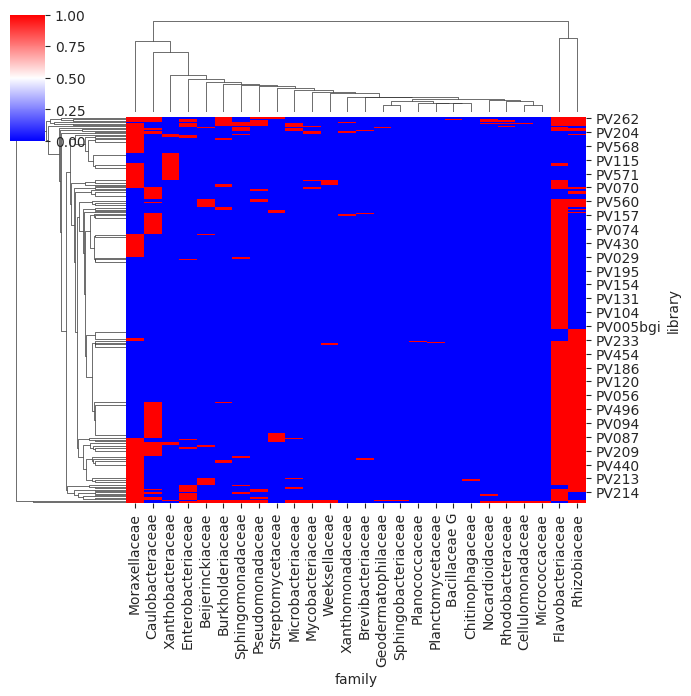

In [65]:
to_c10_order = to_c10.groupby(['library', 'family'])['count'].sum().reset_index()
to_c10_order['detected'] = to_c10_order['count'].apply(lambda x: 0 if pd.isna(x) else 1)
sns.clustermap(to_c10_order.pivot(index='library', columns='family', values='detected').fillna(0), cmap='bwr', figsize=(7,7))

## Co-ocurrence networks

In [ ]:
taxonomy_output

,library,seq_id,taxid,level,species_name,fragments,support,is_unclassified,superkingdom,phylum,...,species,class15,Site_code,Collection_code,Library_code,Location,Host_taxon,Habitat,No_extracts,Date
0,PV051,J00148:55:HN7NMBBXX:5:1206:6532:11618,135553,species,JC017 sp004296775,4,0.6,False,Bacteria,Bacteroidota,...,JC017 sp004296775,Bacteroidia,Q4,Q4P,PV051,Mondéjar,Lotus corniculatus,Oak,13.0,2
1,PV051,J00148:55:HN7NMBBXX:5:2218:30066:28868,71277,species,RGIG9287 sp947165155,2,1.0,False,Bacteria,Bacillota A,...,RGIG9287 sp947165155,Clostridia,Q4,Q4P,PV051,Mondéjar,Lotus corniculatus,Oak,13.0,2
2,PV051,J00148:55:HN7NMBBXX:5:2219:7304:23892,135553,species,JC017 sp004296775,4,0.6,False,Bacteria,Bacteroidota,...,JC017 sp004296775,Bacteroidia,Q4,Q4P,PV051,Mondéjar,Lotus corniculatus,Oak,13.0,2
3,PV051,J00148:55:HN7NMBBXX:5:2224:9983:47348,55265,species,UBA9973 sp027347985,2,1.0,False,Bacteria,Patescibacteria,...,UBA9973 sp027347985,Other,Q4,Q4P,PV051,Mondéjar,Lotus corniculatus,Oak,13.0,2
4,PV051,J00148:55:HN7NMBBXX:5:2211:2138:26652,55151,species,Ferdinandcohnia aciditolerans,2,1.0,False,Bacteria,Bacillota,...,Ferdinandcohnia aciditolerans,Bacilli,Q4,Q4P,PV051,Mondéjar,Lotus corniculatus,Oak,13.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1679981,PV002,J00148:23:HHTNKBBXX:7:2222:6370:42706,79618,species,Streptomyces termitum,2,1.0,False,Bacteria,Actinomycetota,...,Streptomyces termitum,Actinomycetes,M1,M1V,PV002,Aranjuez,Convolvulus arvensis,Crop,11.0,1
1679982,PV002,J00148:23:HHTNKBBXX:7:2223:17888:43075,134412,species,Arthrobacter D sp002929355,4,1.0,False,Bacteria,Actinomycetota,...,Arthrobacter D sp002929355,Actinomycetes,M1,M1V,PV002,Aranjuez,Convolvulus arvensis,Crop,11.0,1
1679983,PV002,J00148:23:HHTNKBBXX:8:2118:20101:35339,44709,species,Flagellimonas alvinocaridis,2,0.5,False,Bacteria,Bacteroidota,...,Flagellimonas alvinocaridis,Bacteroidia,M1,M1V,PV002,Aranjuez,Convolvulus arvensis,Crop,11.0,1
1679984,PV002,J00148:23:HHTNKBBXX:8:2108:2341:1402,1004,genus,Nanosyncoccus,2,1.0,False,Bacteria,Patescibacteria,...,None,Other,M1,M1V,PV002,Aranjuez,Convolvulus arvensis,Crop,11.0,1


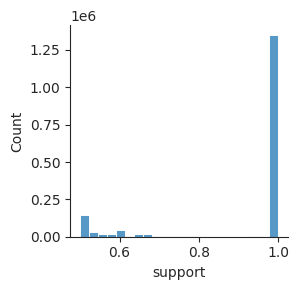

In [ ]:
sns.displot(data=taxonomy_output, x='support', height=3.0)

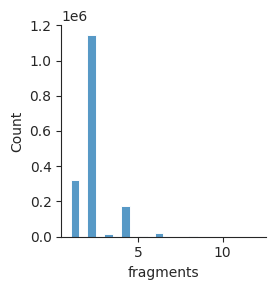

In [ ]:
sns.displot(data=taxonomy_output, x='fragments', height=3.0)

In [ ]:
import networkx as nx

In [ ]:
host_taxid_counts = taxonomy_output.query('class15 != "Other"').dropna(subset=['order']).query('support == 1.0').value_counts(subset=['Host_taxon', 'class', 'order']).reset_index()
host_taxid_counts['Lcount'] = host_taxid_counts['count'].apply(lambda x: np.log10(x))

In [ ]:
# host_taxid_counts = taxonomy_output.query('class15 != "Other"').query('support == 1.0').value_counts(subset=['Host_taxon', 'class']).reset_index()
# host_taxid_counts['Lcount'] = host_taxid_counts['count'].apply(lambda x: np.log10(x))
# host_taxid_counts

,Host_taxon,class,count,Lcount
0,Cynodon dactylon,Alphaproteobacteria,40882,4.611532
1,Conyza bonariensis,Actinomycetes,26351,4.420797
2,Diplotaxis erucoides,Bacteroidia,20785,4.317750
3,Geranium sp,Bacteroidia,20115,4.303520
4,Bromus sp,Gammaproteobacteria,16189,4.209220
...,...,...,...,...
589,Descurainia sophia,Acidimicrobiia,30,1.477121
590,Torilis nodosa,Acidimicrobiia,28,1.447158
591,Poaceae,Acidimicrobiia,24,1.380211
592,Quercus coccifera,Acidimicrobiia,23,1.361728


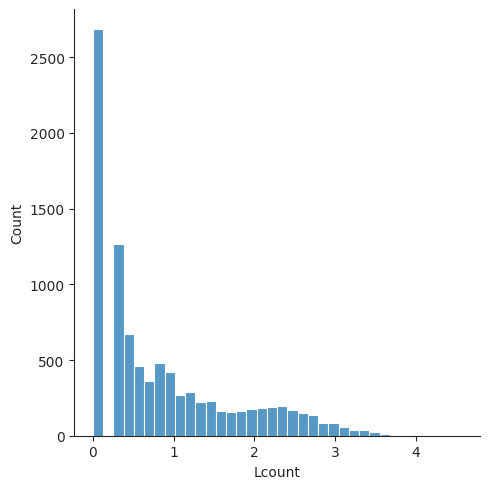

In [ ]:
sns.displot(host_taxid_counts, x='Lcount')

In [ ]:
G = nx.Graph()
for _, row in tqdm.tqdm(list(host_taxid_counts.query('Lcount > 2.0').iterrows())):
    G.add_node(row['Host_taxon'], type='Host')
    G.add_node(row['order'], c=row['class'], type='Bacteria')
    G.add_edge(row['order'], row['Host_taxon'], width=row['Lcount'])

100%|██████████| 1420/1420 [00:00<00:00, 32941.81it/s]


In [ ]:
nx.write_gml(G, '../results/2025-03-19-kraken2-mmseqs2-run/taxid-bacteria-network.gml')